<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/Percobaan_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/kuliah/Data_Mining/credit_data_sample.csv', sep=';')

print(df.head())

Mounted at /content/drive
   Age  Credit_amount  Duration  Employment_since      Purpose
0   25           2000        12                 2          car
1   40           7000        48                 5     business
2   35           3500        24                 4          car
3   23           1200        10                 1    furniture
4   52           9000        60                 5  real_estate


In [ ]:
features = ['Age', 'Credit_amount', 'Duration', 'Employment_since']
X = df[features]

In [ ]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

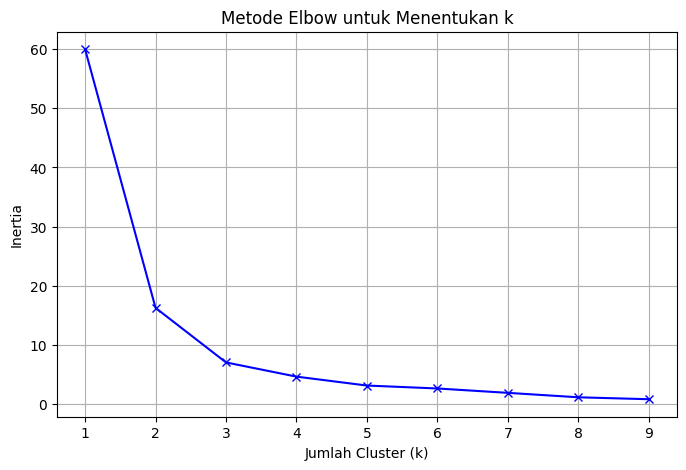

In [ ]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Plot hasil elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [ ]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

   Age  Credit_amount  Duration  Employment_since      Purpose  Cluster
0   25           2000        12                 2          car        2
1   40           7000        48                 5     business        0
2   35           3500        24                 4          car        1
3   23           1200        10                 1    furniture        2
4   52           9000        60                 5  real_estate        0


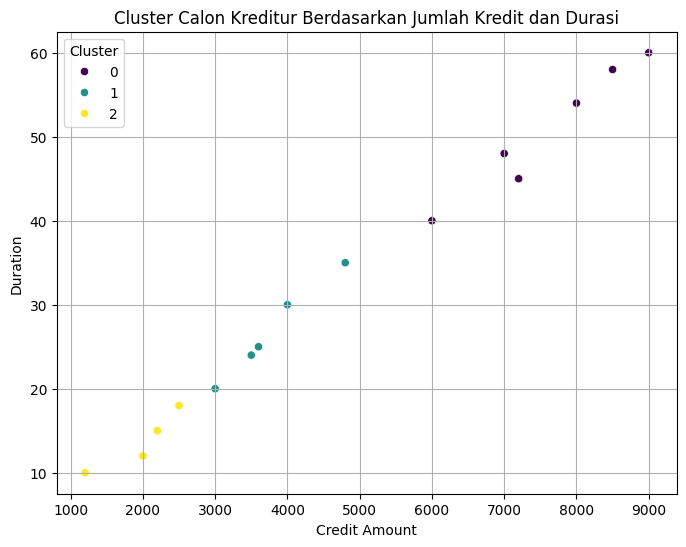

In [ ]:
# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Credit_amount'],
y=df['Duration'], hue=df['Cluster'],
palette='viridis')
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.grid(True)
plt.show()


Silhouette Score: 0.549
Inertia (k=3): 7.016


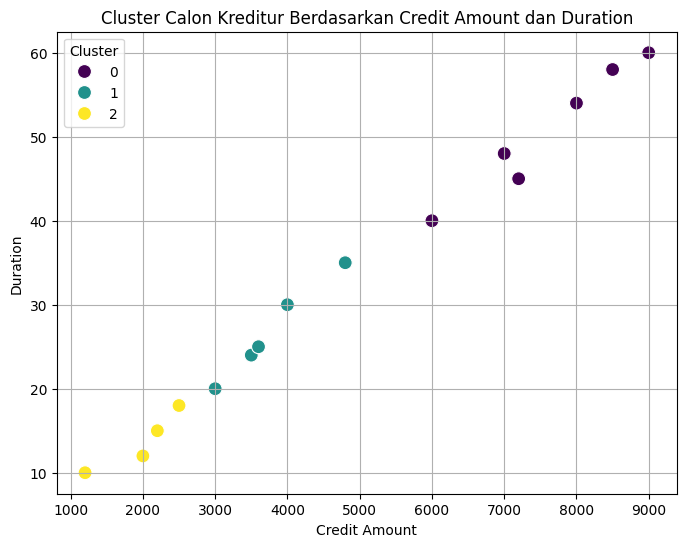

In [ ]:
# 7a. Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled,
df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Step 8 — Visualisasi hasil clustering (2 fitur: Credit_amount vs Duration)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Credit_amount'],
    y=df['Duration'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Cluster Calon Kreditur Berdasarkan Credit Amount dan Duration')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()